In [1]:
from google.colab import files
uploaded = files.upload()

Saving attack_test.pcap to attack_test.pcap
Saving attack_train.pcap to attack_train.pcap
Saving normal_test.pcap to normal_test.pcap
Saving normal_train.pcap to normal_train.pcap


In [2]:
!pip install scapy pandas scikit-learn joblib matplotlib -q

from __future__ import annotations

import csv
from collections import Counter
from pathlib import Path

from scapy.all import DNS, DNSQR, DNSRR, IP, TCP, UDP, rdpcap

DEFAULT_TARGET_DOMAIN = "bank.test"
DEFAULT_FAKE_IP = "172.20.0.60"
DEFAULT_RESOLVER_IP = "172.20.0.10"


def normalize_domain(value):
    if value is None:
        return ""
    if isinstance(value, bytes):
        value = value.decode(errors="ignore")
    return str(value).rstrip(".").lower()


def same_or_subdomain(child, parent):
    child = normalize_domain(child)
    parent = normalize_domain(parent)
    if not child or not parent:
        return 0
    return int(child == parent or child.endswith("." + parent))


def get_dns_name(pkt):
    if pkt.haslayer(DNSQR) and pkt[DNS].qd:
        return normalize_domain(pkt[DNS].qd.qname)
    if pkt.haslayer(DNSRR) and pkt[DNS].an:
        return normalize_domain(pkt[DNS].an.rrname)
    return ""


def iter_dns_rr(rrset, count):
    current = rrset
    for _ in range(int(count or 0)):
        if not current:
            break
        yield current
        current = current.payload if isinstance(current.payload, DNSRR) else None


def iter_dns_records(pkt):
    dns = pkt[DNS]
    sections = (
        ("answer", dns.an, dns.ancount),
        ("authority", dns.ns, dns.nscount),
        ("additional", dns.ar, dns.arcount),
    )
    for section, rrset, count in sections:
        for rr in iter_dns_rr(rrset, count):
            rr_type = getattr(rr, "type", None)
            rr_name = normalize_domain(getattr(rr, "rrname", ""))
            yield {
                "section": section,
                "name": rr_name,
                "type": int(rr_type) if isinstance(rr_type, int) else rr_type,
                "ttl": int(getattr(rr, "ttl", -1)) if hasattr(rr, "ttl") else -1,
                "rdata": str(getattr(rr, "rdata", "")),
            }


def count_records(records, section, rr_type):
    return sum(1 for record in records if record["section"] == section and record["type"] == rr_type)


def extract_row(pkt, index, target_domain, fake_ip, resolver_ip=DEFAULT_RESOLVER_IP):
    if not (pkt.haslayer(IP) and pkt.haslayer(DNS)):
        return None

    dns = pkt[DNS]
    transport = "udp" if pkt.haslayer(UDP) else "tcp" if pkt.haslayer(TCP) else "other"

    if pkt.haslayer(UDP):
        sport = pkt[UDP].sport
        dport = pkt[UDP].dport
    elif pkt.haslayer(TCP):
        sport = pkt[TCP].sport
        dport = pkt[TCP].dport
    else:
        sport = 0
        dport = 0

    qname = get_dns_name(pkt)
    records = list(iter_dns_records(pkt)) if dns.qr == 1 else []
    answer_ips = [record["rdata"] for record in records if record["section"] == "answer" and record["type"] in {1, 28}]
    additional_ips = [record["rdata"] for record in records if record["section"] == "additional" and record["type"] in {1, 28}]
    ttl_values = [record["ttl"] for record in records if record["ttl"] >= 0]

    answer_matches_query_count = sum(
        1 for record in records
        if record["section"] == "answer" and record["name"] == qname
    )
    authority_ns_out_of_bailiwick_count = sum(
        1 for record in records
        if record["section"] == "authority" and record["type"] == 2 and not same_or_subdomain(record["name"], qname)
    )
    additional_out_of_bailiwick_count = sum(
        1 for record in records
        if record["section"] == "additional" and record["name"] and not same_or_subdomain(record["name"], qname)
    )

    label = int(dns.qr == 1 and fake_ip in set(answer_ips + additional_ips))
    ttl_min = min(ttl_values) if ttl_values else -1
    ttl_max = max(ttl_values) if ttl_values else -1

    return {
        "packet_index": index,
        "timestamp": float(pkt.time),
        "src_ip": pkt[IP].src,
        "dst_ip": pkt[IP].dst,
        "transport": transport,
        "src_port": int(sport),
        "dst_port": int(dport),
        "src_port_is_dns": int(sport == 53),
        "dst_port_is_dns": int(dport == 53),
        "dst_is_resolver": int(pkt[IP].dst == resolver_ip),
        "dns_id": int(dns.id),
        "is_response": int(dns.qr),
        "opcode": int(dns.opcode),
        "rcode": int(dns.rcode),
        "aa": int(dns.aa),
        "tc": int(dns.tc),
        "rd": int(dns.rd),
        "ra": int(dns.ra),
        "qdcount": int(dns.qdcount or 0),
        "ancount": int(dns.ancount or 0),
        "nscount": int(dns.nscount or 0),
        "arcount": int(dns.arcount or 0),
        "record_total": len(records),
        "answer_a_count": count_records(records, "answer", 1),
        "answer_aaaa_count": count_records(records, "answer", 28),
        "answer_ns_count": count_records(records, "answer", 2),
        "answer_cname_count": count_records(records, "answer", 5),
        "authority_ns_count": count_records(records, "authority", 2),
        "authority_soa_count": count_records(records, "authority", 6),
        "additional_a_count": count_records(records, "additional", 1),
        "additional_aaaa_count": count_records(records, "additional", 28),
        "additional_ns_count": count_records(records, "additional", 2),
        "additional_cname_count": count_records(records, "additional", 5),
        "has_authority_ns": int(count_records(records, "authority", 2) > 0),
        "has_additional_a": int(count_records(records, "additional", 1) > 0),
        "answer_matches_query_count": answer_matches_query_count,
        "authority_ns_out_of_bailiwick_count": authority_ns_out_of_bailiwick_count,
        "additional_out_of_bailiwick_count": additional_out_of_bailiwick_count,
        "qname": qname,
        "qname_len": len(qname),
        "is_target_domain": int(qname == target_domain),
        "answer_ips": "|".join(answer_ips),
        "additional_ips": "|".join(additional_ips),
        "has_fake_ip": int(fake_ip in set(answer_ips + additional_ips)),
        "min_ttl": ttl_min,
        "max_ttl": ttl_max,
        "ttl_span": (ttl_max - ttl_min) if ttl_values else -1,
        "packet_len": int(len(pkt)),
        "label": label,
    }


def build_summary(rows, pcap_path, output_path):
    label_counts = Counter(int(row["label"]) for row in rows)
    response_counts = Counter(int(row["is_response"]) for row in rows)
    fake_ip_count = sum(int(row["has_fake_ip"]) for row in rows)
    target_count = sum(int(row["is_target_domain"]) for row in rows)
    resolver_bound_response_count = sum(
        int(row["is_response"] == 1 and row["dst_is_resolver"] == 1) for row in rows
    )
    qname_counts = Counter(str(row["qname"]) for row in rows if row["qname"])

    lines = [
        "DNS Packet CSV Conversion Summary",
        "=" * 34,
        f"Input pcap: {pcap_path}",
        f"Output csv: {output_path}",
        f"Total DNS rows: {len(rows)}",
        "",
        "Label counts",
        f"- normal(label=0): {label_counts.get(0, 0)}",
        f"- attack(label=1): {label_counts.get(1, 0)}",
        "",
        "Packet direction",
        f"- query(is_response=0): {response_counts.get(0, 0)}",
        f"- response(is_response=1): {response_counts.get(1, 0)}",
        f"- resolver-bound responses: {resolver_bound_response_count}",
        "",
        "Target indicators",
        f"- target-domain rows: {target_count}",
        f"- rows containing fake IP: {fake_ip_count}",
        "",
        "Top queried names",
    ]

    for name, count in qname_counts.most_common(5):
        lines.append(f"- {name}: {count}")

    return "\n".join(lines) + "\n"


def convert_pcap_to_csv(
    pcap_file,
    output_file,
    target_domain=DEFAULT_TARGET_DOMAIN,
    fake_ip=DEFAULT_FAKE_IP,
    resolver_ip=DEFAULT_RESOLVER_IP,
    summary_file=None,
):
    pcap_path = Path(pcap_file)
    output_path = Path(output_file)
    target_domain = normalize_domain(target_domain)

    if summary_file is None:
        summary_path = output_path.with_name(f"{output_path.stem}_summary.txt")
    else:
        summary_path = Path(summary_file)

    packets = rdpcap(str(pcap_path))
    output_path.parent.mkdir(parents=True, exist_ok=True)

    rows = []
    for index, pkt in enumerate(packets):
        row = extract_row(pkt, index, target_domain, fake_ip, resolver_ip=resolver_ip)
        if row is not None:
            row["source_file"] = pcap_path.name
            rows.append(row)

    if not rows:
        raise ValueError("No DNS packets were found in the pcap file.")

    with output_path.open("w", newline="", encoding="utf-8") as file:
        writer = csv.DictWriter(file, fieldnames=list(rows[0].keys()))
        writer.writeheader()
        writer.writerows(rows)

    summary = build_summary(rows, pcap_path, output_path)
    print(summary)

    summary_path.parent.mkdir(parents=True, exist_ok=True)
    summary_path.write_text(summary, encoding="utf-8")

    print(f"[+] Wrote {len(rows)} DNS packet rows to {output_path}")
    print(f"[+] Wrote conversion summary to {summary_path}")

    return len(rows)


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 29.1 MB/s eta 0:00:00


In [3]:
!pip install pandas scikit-learn joblib matplotlib -q

from pathlib import Path

import joblib
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder


LABEL_COLUMN = "label"
RESPONSE_ONLY = True
RESOLVER_BOUND_RESPONSES_ONLY = True
DEFAULT_RESOLVER_IP = "172.20.0.10"

# Default hard-test feature policy:
# - remove dataset shortcuts that dominated the previous model
# - keep DNS structure features so the model has to learn packet shape
# - avoid raw IP/port/name fields that memorize this lab topology
SHORTCUT_COLUMNS = {
    "qname_len",
    "dns_id",
    "is_response",
    "aa",
    "ra",
    "rcode",
    "is_target_domain",
    "has_fake_ip",
    "min_ttl",
    "max_ttl",
    "ttl_span",
    "src_port",
    "dst_port",
    "src_port_is_dns",
    "dst_port_is_dns",
    "dst_is_resolver",
    "packet_len",
}

META_COLUMNS = {
    "packet_index",
    "timestamp",
    "src_ip",
    "dst_ip",
    "qname",
    "answer_ips",
    "additional_ips",
    "source_file",
    "run_id",
    LABEL_COLUMN,
}

DROP_COLUMNS = META_COLUMNS | SHORTCUT_COLUMNS
CATEGORICAL_COLUMNS = ["transport"]


def filter_training_scope(frame, name):
    filtered = frame.copy()
    if RESPONSE_ONLY and "is_response" in filtered.columns:
        filtered = filtered[filtered["is_response"] == 1].copy()
    if RESOLVER_BOUND_RESPONSES_ONLY and "dst_ip" in filtered.columns:
        filtered = filtered[filtered["dst_ip"] == DEFAULT_RESOLVER_IP].copy()

    if filtered.empty:
        raise ValueError(f"{name} data is empty after response/resolver-bound filtering.")
    return filtered


def build_feature_table(frame, name="Dataset"):
    if LABEL_COLUMN not in frame.columns:
        raise ValueError("CSV must include a 'label' column.")

    frame = filter_training_scope(frame, name)
    y = frame[LABEL_COLUMN].astype(int)
    x = frame.drop(columns=[column for column in DROP_COLUMNS if column in frame.columns])
    return x, y, frame


def require_binary_labels(y, name):
    if y.nunique() < 2:
        raise ValueError(f"{name} data needs both normal(label=0) and attack(label=1) rows. Current: {y.value_counts().to_dict()}")

    class_counts = y.value_counts()
    if int(class_counts.min()) < 2:
        raise ValueError(
            f"Each class in {name} data needs at least 2 rows. "
            f"Current label counts: {class_counts.to_dict()}"
        )


def align_test_columns(x_train, x_test):
    missing = [column for column in x_train.columns if column not in x_test.columns]
    extra = [column for column in x_test.columns if column not in x_train.columns]

    if missing:
        print(f"[!] Test CSV is missing train columns; filling with 0: {missing}")
    if extra:
        print(f"[!] Test CSV has extra columns ignored by the model: {extra}")

    return x_test.reindex(columns=x_train.columns, fill_value=0)


def build_pipeline(feature_columns):
    categorical = [column for column in CATEGORICAL_COLUMNS if column in feature_columns]
    numeric = [column for column in feature_columns if column not in categorical]

    preprocess = ColumnTransformer(
        transformers=[
            ("numeric", SimpleImputer(strategy="median"), numeric),
            (
                "categorical",
                Pipeline(
                    steps=[
                        ("imputer", SimpleImputer(strategy="most_frequent")),
                        ("onehot", OneHotEncoder(handle_unknown="ignore")),
                    ]
                ),
                categorical,
            ),
        ],
        remainder="drop",
    )

    forest = RandomForestClassifier(
        class_weight="balanced",
        n_jobs=1,
        random_state=42,
    )

    return Pipeline(
        steps=[
            ("preprocess", preprocess),
            ("model", forest),
        ]
    )


def get_feature_importance(search):
    best_pipeline = search.best_estimator_
    preprocess = best_pipeline.named_steps["preprocess"]
    model = best_pipeline.named_steps["model"]
    feature_names = preprocess.get_feature_names_out()
    importances = model.feature_importances_

    return (
        pd.DataFrame({"feature": feature_names, "importance": importances})
        .sort_values("importance", ascending=False)
        .reset_index(drop=True)
    )


def false_positive_rate(y_true, predictions):
    matrix = confusion_matrix(y_true, predictions, labels=[0, 1])
    tn, fp, fn, tp = matrix.ravel()
    return fp / (fp + tn) if (fp + tn) else 0.0


def visualize_results(y_test, predictions, importance):
    accuracy = accuracy_score(y_test, predictions)
    fpr = false_positive_rate(y_test, predictions)

    print(f"Accuracy: {accuracy:.4f}")
    print(f"False Positive Rate: {fpr:.4f}")
    print("\nClassification Report")
    print(
        classification_report(
            y_test,
            predictions,
            target_names=["Normal", "Attack"],
            digits=4,
        )
    )

    matrix = confusion_matrix(y_test, predictions, labels=[0, 1])
    disp = ConfusionMatrixDisplay(
        confusion_matrix=matrix,
        display_labels=["Normal", "Attack"],
    )
    disp.plot(values_format="d")
    plt.title("Confusion Matrix")
    plt.show()

    report_dict = classification_report(
        y_test,
        predictions,
        target_names=["Normal", "Attack"],
        output_dict=True,
    )
    report_df = pd.DataFrame(report_dict).transpose()
    score_df = report_df.loc[["Normal", "Attack"], ["precision", "recall", "f1-score"]]
    score_df.plot(kind="bar", figsize=(8, 5))
    plt.title("Precision / Recall / F1-score")
    plt.xlabel("Class")
    plt.ylabel("Score")
    plt.ylim(0, 1.05)
    plt.xticks(rotation=0)
    plt.grid(axis="y")
    plt.show()

    top_importance = importance.head(10)
    plt.figure(figsize=(10, 6))
    plt.barh(top_importance["feature"], top_importance["importance"])
    plt.xlabel("Importance")
    plt.title("Top 10 Feature Importances")
    plt.gca().invert_yaxis()
    plt.show()


def tune_and_train(
    csv_file,
    test_csv_file,
    model_file="random_forest_model.joblib",
    report_file="training_report.txt",
    importance_file="feature_importance.csv",
):
    train_path = Path(csv_file)
    test_path = Path(test_csv_file)
    model_path = Path(model_file)
    report_path = Path(report_file)
    importance_path = Path(importance_file)

    train_frame = pd.read_csv(train_path)
    test_frame = pd.read_csv(test_path)

    x_train, y_train, filtered_train = build_feature_table(train_frame, "Training")
    x_test, y_test, filtered_test = build_feature_table(test_frame, "Test")
    x_test = align_test_columns(x_train, x_test)

    require_binary_labels(y_train, "Training")
    require_binary_labels(y_test, "Test")

    pipeline = build_pipeline(list(x_train.columns))

    param_grid = {
        "model__n_estimators": [100, 200],
        "model__max_depth": [None, 8, 16],
        "model__min_samples_split": [2, 5],
        "model__min_samples_leaf": [1, 2],
        "model__max_features": ["sqrt", "log2"],
    }

    train_min_class_count = int(y_train.value_counts().min())
    cv_splits = min(3, train_min_class_count)
    if cv_splits < 2:
        raise ValueError(
            "Each class needs at least 2 training rows. "
            f"Training label counts: {y_train.value_counts().to_dict()}"
        )

    cv = StratifiedKFold(
        n_splits=cv_splits,
        shuffle=True,
        random_state=42,
    )

    search = GridSearchCV(
        estimator=pipeline,
        param_grid=param_grid,
        scoring="f1",
        cv=cv,
        n_jobs=1,
        verbose=1,
    )

    search.fit(x_train, y_train)
    predictions = search.predict(x_test)
    importance = get_feature_importance(search)

    joblib.dump(
        {
            "model": search.best_estimator_,
            "feature_columns": list(x_train.columns),
            "best_params": search.best_params_,
            "drop_columns": sorted(DROP_COLUMNS),
            "response_only": RESPONSE_ONLY,
            "resolver_bound_responses_only": RESOLVER_BOUND_RESPONSES_ONLY,
        },
        model_path,
    )

    report = classification_report(y_test, predictions, digits=4)
    matrix = confusion_matrix(y_test, predictions, labels=[0, 1])
    fpr = false_positive_rate(y_test, predictions)

    result = (
        "Random Forest Training Summary\n"
        "==============================\n"
        f"Train csv: {train_path}\n"
        f"Test csv: {test_path}\n"
        f"Raw train rows: {len(train_frame)}\n"
        f"Raw test rows: {len(test_frame)}\n"
        f"Filtered train rows: {len(filtered_train)}\n"
        f"Filtered test rows: {len(filtered_test)}\n"
        f"Features before encoding: {len(x_train.columns)}\n"
        f"Dropped shortcut columns: {sorted(SHORTCUT_COLUMNS)}\n"
        f"Train label counts: {y_train.value_counts().sort_index().to_dict()}\n"
        f"Test label counts: {y_test.value_counts().sort_index().to_dict()}\n"
        f"CV folds: {cv_splits}\n"
        f"Saved model: {model_path}\n\n"
        f"Best parameters:\n{search.best_params_}\n\n"
        f"False positive rate: {fpr:.4f}\n\n"
        f"Confusion matrix:\n{matrix}\n\n"
        f"Classification report:\n{report}\n"
        f"\nTop feature importances:\n{importance.head(10).to_string(index=False)}\n"
    )

    print(result)
    report_path.write_text(result, encoding="utf-8")
    importance.to_csv(importance_path, index=False)

    print(f"[+] Wrote trained model to {model_path}")
    print(f"[+] Wrote training report to {report_path}")
    print(f"[+] Wrote feature importances to {importance_path}")

    visualize_results(y_test, predictions, importance)

    return search


In [4]:
PCAP_DIR = Path("pcaps") if Path("pcaps").exists() else Path(".")

TRAIN_PCAPS = [
    (PCAP_DIR / "normal_train.pcap", "normal_train.csv"),
    (PCAP_DIR / "attack_train.pcap", "attack_train.csv"),
]

TEST_PCAPS = [
    (PCAP_DIR / "normal_test.pcap", "normal_test.csv"),
    (PCAP_DIR / "attack_test.pcap", "attack_test.csv"),
]

for pcap_file, csv_file in TRAIN_PCAPS + TEST_PCAPS:
    convert_pcap_to_csv(
        pcap_file=pcap_file,
        output_file=csv_file,
    )

train = pd.concat(
    [pd.read_csv(csv_file) for _, csv_file in TRAIN_PCAPS],
    ignore_index=True,
)

test = pd.concat(
    [pd.read_csv(csv_file) for _, csv_file in TEST_PCAPS],
    ignore_index=True,
)

train.to_csv("train.csv", index=False)
test.to_csv("test.csv", index=False)

print("Train labels")
print(train["label"].value_counts().sort_index())
print("\nTest labels")
print(test["label"].value_counts().sort_index())


DNS Packet CSV Conversion Summary
Input pcap: normal_train.pcap
Output csv: normal_train.csv
Total DNS rows: 291235

Label counts
- normal(label=0): 291235
- attack(label=1): 0

Packet direction
- query(is_response=0): 145618
- response(is_response=1): 145617

Target indicators
- target-domain rows: 0
- rows containing fake IP: 0

Top queried names
- www.google.external.test: 14506
- google.external.test: 8780
- www.youtube.external.test: 6528
- www.naver.external.test: 4136
- youtube.external.test: 3946

[+] Wrote 291235 DNS packet rows to normal_train.csv
[+] Wrote conversion summary to normal_train_summary.txt
DNS Packet CSV Conversion Summary
Input pcap: attack_train.pcap
Output csv: attack_train.csv
Total DNS rows: 65536

Label counts
- normal(label=0): 0
- attack(label=1): 65536

Packet direction
- query(is_response=0): 0
- response(is_response=1): 65536

Target indicators
- target-domain rows: 65536
- rows containing fake IP: 65536

Top queried names
- bank.test: 65536

[+] Wrot

In [5]:
train_df = pd.read_csv("train.csv")
test_df = pd.read_csv("test.csv")

print("Train preview")
print(train_df.head())
print(train_df["label"].value_counts().sort_index())

print("\nTest preview")
print(test_df.head())
print(test_df["label"].value_counts().sort_index())


Train preview
   packet_index     timestamp       src_ip       dst_ip transport  src_port  \
0             0  1.779503e+09  172.20.0.40  172.20.0.10       udp     49036   
1             1  1.779503e+09  172.20.0.10  172.20.0.80       udp      1025   
2             2  1.779503e+09  172.20.0.80  172.20.0.10       udp        53   
3             3  1.779503e+09  172.20.0.10  172.20.0.40       udp        53   
4             4  1.779503e+09  172.20.0.40  172.20.0.10       udp     37259   

   dst_port  dns_id  is_response  opcode  ...  qname_len  is_target_domain  \
0        53    4105            0       0  ...         28                 0   
1        53   35746            0       0  ...         28                 0   
2      1025   35746            1       0  ...         28                 0   
3     49036    4105            1       0  ...         28                 0   
4        53    2241            0       0  ...         28                 0   

       answer_ips  has_fake_ip  min_ttl  m

In [6]:
train = pd.read_csv("train.csv")

print(train["label"].value_counts())
print(train[["qname", "answer_ips", "has_fake_ip", "is_target_domain", "label"]].head(20))
print(train[train["answer_ips"].astype(str).str.contains("172.20.0.60", na=False)][["qname", "answer_ips", "has_fake_ip", "is_target_domain", "label"]].head())

label
0    291235
1     65536
Name: count, dtype: int64
                            qname      answer_ips  has_fake_ip  \
0    img.domain0524.external.test             NaN            0   
1    img.domain0524.external.test             NaN            0   
2    img.domain0524.external.test  10.203.167.239            0   
3    img.domain0524.external.test  10.203.167.239            0   
4    www.domain0273.external.test             NaN            0   
5    www.domain0273.external.test             NaN            0   
6    www.domain0273.external.test             NaN            0   
7   edge.domain0273.external.test             NaN            0   
8   edge.domain0273.external.test  10.147.111.111            0   
9    www.domain0273.external.test             NaN            0   
10    login.youtube.external.test             NaN            0   
11    login.youtube.external.test             NaN            0   
12    login.youtube.external.test    10.38.80.138            0   
13    login.youtube.

Fitting 3 folds for each of 48 candidates, totalling 144 fits
Random Forest Training Summary
Train csv: train.csv
Test csv: test.csv
Train rows: 356771
Test rows: 112384
Features before encoding: 10
Train label counts: {0: 145617, 1: 65536}
Test label counts: {0: 46202, 1: 19979}
CV folds: 3
Saved model: random_forest_model.joblib

Best parameters:
{'model__max_depth': None, 'model__max_features': 'sqrt', 'model__min_samples_leaf': 1, 'model__min_samples_split': 2, 'model__n_estimators': 100}

False positive rate: 0.0000

Confusion matrix:
[[46202     0]
 [    0 19979]]

Classification report:
              precision    recall  f1-score   support

           0     1.0000    1.0000    1.0000     46202
           1     1.0000    1.0000    1.0000     19979

    accuracy                         1.0000     66181
   macro avg     1.0000    1.0000    1.0000     66181
weighted avg     1.0000    1.0000    1.0000     66181


Top feature importances:
                   feature  importance
       

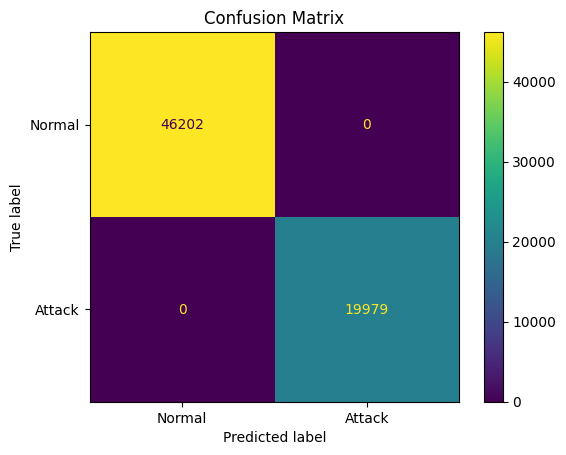

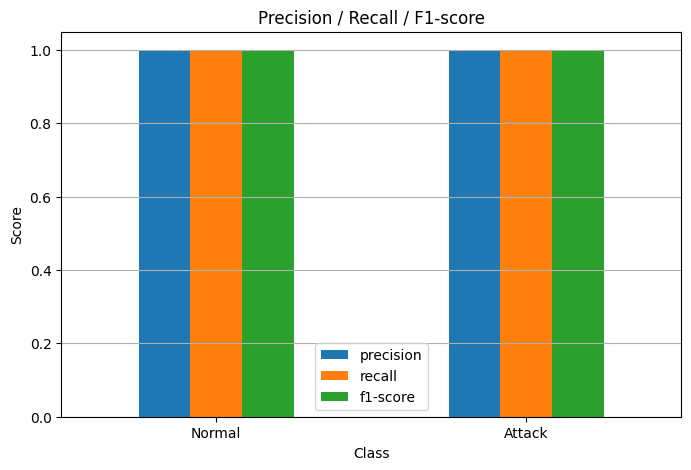

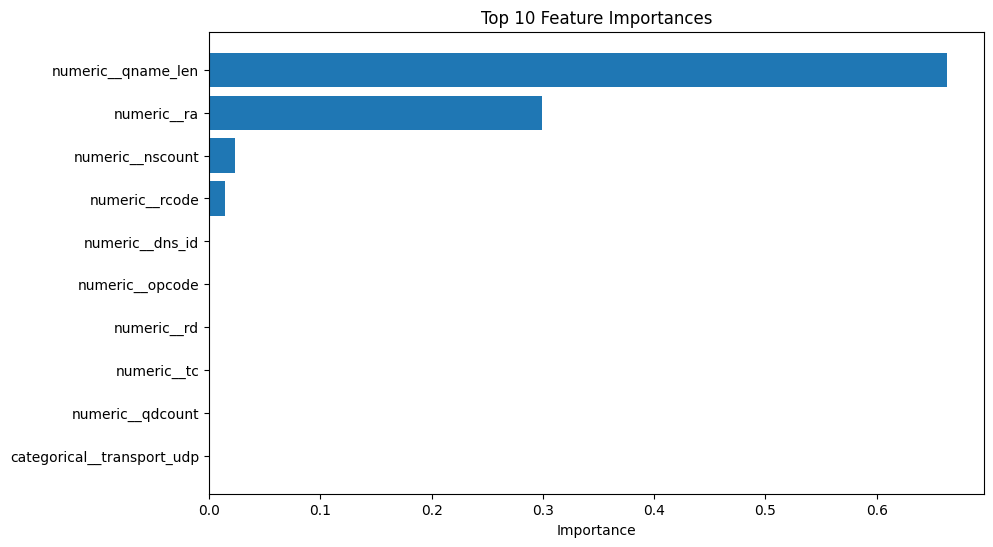

In [7]:
search = tune_and_train(
    csv_file="train.csv",
    test_csv_file="test.csv",
    model_file="random_forest_model.joblib",
    report_file="training_report.txt",
    importance_file="feature_importance.csv",
)


In [ ]:
from google.colab import files

files.download("random_forest_model.joblib")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>